# Coupled ABM — FloodAdapt × DYNAMO-M — practical guide

**What this notebook does.** It simulates how a population of coastal households decides —
year after year, under **rising sea level** and stochastic flood events — whether to *floodproof*
their homes, and it quantifies the **damages** those decisions avoid. It couples two models:

- **FloodAdapt** supplies the *physics*: a pre-computed **lookup table** of flood **damage per
  building, per sea-level-rise (SLR) step, per event, per adaptation strategy**.
- **DYNAMO-M** supplies the *behaviour*: a **Subjective Expected Utility (SEU)** decision that
  each household uses to weigh the cost of floodproofing against its perceived flood risk.

### Executive summary (read this first)
| Question a manager asks | Where the notebook answers it |
|---|---|
| *How many households protect themselves over time?* | **# adapted per year** plot (§8) |
| *What flood damage do we still incur?* | **total damage per year** plot (§8) |
| *What damage does adaptation avoid?* | **total avoided damage per year** plot (§8) |
| *How uncertain are these numbers?* | 3 Monte-Carlo **sequences** + mean ± s.d. (§7–§8) |
| *Is this trustworthy / reproducible?* | fixed seeds; two independent run paths give **identical** results (§10) |

We run a **30-year** horizon, **3 Monte-Carlo sequences**, allowing up to **5 flood events per
year**. Everything is driven by the SLR trajectory, which we plot next to every result so the
outcomes can always be read against the sea-level driver.

> **Two ways to run, one answer.** The *preferred* path uses the real **honeybees** agent-based
> framework and the native DYNAMO-M decision code (§6). A *portable mirror* reproduces the exact
> same numbers with **no mesa/honeybees install required** (§10). We prove they are bit-for-bit
> identical.


## 1. Setup

Imports and environment provenance. The `_shared` helper (from `examples_engine/`) bootstraps the package path and loads either the real Charleston lookup table or a fast synthetic stand-in.

In [1]:
import sys, os, platform
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Make floodadapt_abm importable and reuse the examples' dataset loader.
_REPO = Path.cwd()
sys.path.insert(0, str(_REPO))
sys.path.insert(0, str(_REPO / "examples_engine"))
from _shared import load_dataset  # noqa: E402

import floodadapt_abm as fabm
from floodadapt_abm import (
    SimulationEngine, CouplingConfig, DecisionConfig,
    SEURule, ThresholdRule, DynamoLiveRule,
    run_mesa_native, run_mesa_native_full,
    DYNAMO_M_AVAILABLE, HONEYBEES_AVAILABLE,
)

print("Python           :", platform.python_version())
print("numpy / xarray   :", np.__version__, "/", xr.__version__)
print("honeybees present:", HONEYBEES_AVAILABLE, " (real Mesa/honeybees run path)")
print("DYNAMO-M present :", DYNAMO_M_AVAILABLE, " (native DecisionModule parity)")

Python           : 3.11.14
numpy / xarray   : 1.26.4 / 2025.11.0
honeybees present: True  (real Mesa/honeybees run path)
DYNAMO-M present : True  (native DecisionModule parity)


## 2. The coupled architecture, concisely

One **kernel** does the numeric work every simulated year; a pluggable **decision rule** owns
the behaviour; a **clock** owns time. The three run paths differ *only* in who owns the clock —
they share the identical kernel and RNG stream, so they produce identical numbers.

```
        FloodAdapt lookup table (damage[obj, slr, strategy, event])
                              │
                              ▼
                 LookupTableAdapter  ──►  per-agent AgentState  (wealth, risk perception,
                              │                                   adaptation status, time_adapt)
                              ▼
   ┌──────────────────────────────────────────────────────────────┐
   │  SimulationEngine.step(year, slr_t, rng)   ← THE shared kernel │
   │    1. draw stochastic events (Bernoulli, cap = max_events/yr)  │
   │    2. interpolate damage at slr_t for each strategy            │
   │    3. ask the DECISION RULE: adapt or not?                     │
   │    4. update state (damages, adopted, floodproof lifespan)     │
   └──────────────────────────────────────────────────────────────┘
              ▲ decision rule (Strategy Pattern)         ▲ clock owner
   ┌──────────┴───────────┐                   ┌──────────┴────────────────────┐
   │ SEURule  (ported EU) │                   │ engine.run         (own loop) │
   │ DynamoLiveRule (native DYNAMO-M) │  ◄──►  │ run_mesa_native    (mirror)   │
   │ ThresholdRule (legacy)          │        │ run_mesa_native_full (honeybees Model) │
   └──────────────────────┘                   └───────────────────────────────┘
```

| Piece | Responsibility | Provided by |
|---|---|---|
| Lookup table | Flood damage per building / SLR / event / strategy | **FloodAdapt** |
| `LookupTableAdapter` | Map table → agent arrays; interpolate at each SLR | this repo |
| `SimulationEngine.step` | The single per-year kernel (events, damage, state) | this repo |
| Decision rule | Adapt-or-not each year (SEU / native / threshold) | DYNAMO-M science, pluggable |
| Clock owner | Advances the year loop | `engine.run` / `run_mesa_native` / `run_mesa_native_full` |


## 3. Why a lightweight `AgentState` instead of full DYNAMO-M

DYNAMO-M is a large geospatial model (GLOFRIS hazard layers, gravity-based migration, coastal
amenities, population dynamics, on-disk water-level maps). For the **MVP coupling** we deliberately
use a **lightweight in-memory `AgentState`** — a handful of NumPy arrays (wealth, risk perception,
adaptation status, floodproofing age) — instead of instantiating the full model.

**Why this is the right MVP choice**

- **Scope.** The coupling question is *"does the FloodAdapt damage signal drive DYNAMO-M-style
  adaptation decisions correctly?"* That needs the **decision math**, not the geospatial stack.
- **Portability.** The lightweight state runs anywhere — no GLOFRIS rasters, no DYNAMO-M checkout,
  no honeybees required for the mirror path — which keeps the notebook and CI reproducible.
- **Fidelity where it matters.** The actual decision can still be the **native DYNAMO-M
  `DecisionModule`** (via `DynamoLiveRule`); we validated its Subjective Expected Utility against
  DYNAMO-M to `~1e-6` (Phase 4a). So we get native decision fidelity *without* the heavy ecosystem.
- **Bit-parity contract.** Because state is small and deterministic, every run path is provably
  identical (§10) — essential for trustworthy results.

**When you would reach for full DYNAMO-M instead:** migration/relocation dynamics, government or
dike cost-benefit, coastal-amenity feedbacks, or real GLOFRIS hazard maps. Those are **future
phases** and slot in as new rules/agents, not as changes to this kernel.


## 4. Monte-Carlo **sequences** and **multiprocessing**

**Sequences.** Flood events are *stochastic*: each year, each event either happens or not
(Bernoulli draw, capped at `max_events_per_year`). A single run is therefore just one possible
"weather history". We run **several independent sequences** (here **3**) with different random
streams and report the **mean ± spread** — that is the uncertainty band in every plot below.
Sequence `s` uses seed `base_seed + s`, so results are fully reproducible.

**Multiprocessing.** Sequences are independent, so they parallelise perfectly.
`engine.run(..., n_jobs=N)` fans the sequences across a thread pool of per-worker engine clones
that share one pre-warmed, read-only interpolation cache. Key guarantees:

- `n_jobs=-1` uses all cores; `n_jobs=1` is the sequential path.
- The parallel result is **bit-identical** to sequential (each sequence owns its RNG and output
  slice) — speed, not different numbers.

> The *preferred* honeybees path (`run_mesa_native_full`) advances one genuine model clock, so it
> loops its sequences **serially**. When you need many sequences fast, run the **identical**
> `engine.run(n_jobs=-1)` — §10 shows the two agree bit-for-bit.


## 5. Configuration

The scenario knobs. `DecisionConfig` carries the **validated MVP settings** (calibrated to
DYNAMO-M `settings.yml`); here we only override `max_events_per_year = 5` and keep the 75-year
floodproofing lifespan. Set `USE_REAL_TABLE = True` (or `FA_ABM_REAL_TABLE=1`) to run on the real
1.96 GB Charleston table — accurate but minutes-scale; the default synthetic table runs in seconds.

In [2]:
# --- Scenario ---------------------------------------------------------------
START_YEAR         = 2020
N_YEARS            = 30
NO_SEQ             = 3          # Monte-Carlo sequences
MAX_EVENTS_PER_YR  = 5
SEED               = 42

# --- Dataset: synthetic by default, real Charleston table opt-in ------------
USE_REAL_TABLE = os.environ.get("FA_ABM_REAL_TABLE", "0") not in ("0", "", "false", "False")
ds, source = load_dataset(prefer_real=USE_REAL_TABLE)
print(f"Lookup table : {source}")
print(f"dimensions   : {dict(ds.sizes)}")

# --- Decision / coupling configuration --------------------------------------
config = CouplingConfig(
    decision=DecisionConfig(max_events_per_year=MAX_EVENTS_PER_YR),  # lifespan_dryproof=75 default
    random_seed=SEED,
)

# --- SLR trajectory (the driver) --------------------------------------------
# Preferred, if a FloodAdapt database is available:
#   import flood_adapt.api as fa
#   slr_values = np.array([fa.interp_slr(slr_scenario="NOAA High", year=START_YEAR+t)
#                          for t in range(N_YEARS)])
# Fallback: a linear ramp across the lookup table's SLR grid.
slr_values = np.linspace(float(ds.slr.min()), float(ds.slr.max()), N_YEARS)
years = START_YEAR + np.arange(N_YEARS)
print(f"SLR trajectory: {slr_values[0]:.2f} -> {slr_values[-1]:.2f} "
      f"({ds.slr.attrs.get('units', 'table units')}) over {N_YEARS} years")

Lookup table : synthetic Charleston-like table (generated)
dimensions   : {'object_id': 200, 'slr': 5, 'strategy': 2, 'event': 6}
SLR trajectory: 0.00 -> 2.00 (table units) over 30 years


## 6. Preferred run — `run_mesa_native_full` (honeybees-driven)

We build the shared `SimulationEngine` and a **decision rule**. If a DYNAMO-M checkout is present
we use the **native `DecisionModule`** (`DynamoLiveRule`) for maximum fidelity; otherwise the
validated ported `SEURule` (identical MVP math). Then `run_mesa_native_full` advances a genuine
**honeybees `Model`** clock over the horizon. If honeybees is not installed we fall back to the
portable mirror `run_mesa_native` — the numbers are identical either way (proven in §10).

In [3]:
engine = SimulationEngine(ds=ds, config=config)
print(f"residential agents: {engine.n_agents}")

# Prefer the native DYNAMO-M decision module when available; else the ported SEURule.
if DYNAMO_M_AVAILABLE:
    engine.decision_rule = DynamoLiveRule(config.decision)
    rule_label = "native DYNAMO-M DecisionModule (DynamoLiveRule)"
else:
    engine.decision_rule = SEURule(config.decision)
    rule_label = "ported SEURule (DYNAMO-M SEU math)"
print("decision rule    :", rule_label)

# Preferred honeybees-driven run; portable mirror if honeybees is absent.
if HONEYBEES_AVAILABLE:
    run_label = "run_mesa_native_full (real honeybees Model clock)"
    results = run_mesa_native_full(engine, slr_values, no_seq=NO_SEQ, seed=SEED,
                                   track_eu=True, start_year=START_YEAR)
else:
    run_label = "run_mesa_native (dependency-free mirror; honeybees not installed)"
    results = run_mesa_native(engine, slr_values, no_seq=NO_SEQ, seed=SEED, track_eu=True)
print("run path         :", run_label)

damage   = results["damage_history"].astype(np.float64)   # (NO_SEQ, n_agents, N_YEARS)
adopted  = results["adapted_history"]                      # bool, same shape
adoption = results["adoption_fraction"]                    # (NO_SEQ, N_YEARS)
n_adapted = adopted.sum(axis=1)                            # (NO_SEQ, N_YEARS) households adapted
print("result arrays    :", {k: v.shape for k, v in results.items() if hasattr(v, "shape")})

residential agents: 160


decision rule    : native DYNAMO-M DecisionModule (DynamoLiveRule)


run path         : run_mesa_native_full (real honeybees Model clock)
result arrays    : {'damage_history': (3, 160, 30), 'adapted_history': (3, 160, 30), 'adoption_fraction': (3, 30), 'eu_adapt_history': (3, 160, 30), 'eu_do_nothing_history': (3, 160, 30)}


## 7. Results per sequence + statistics

To measure **avoided** damage we run an identical never-adapt **baseline** (a threshold that is
never reached, and no floodproofing lifespan). Avoided damage = baseline − adaptive, per year.
We then summarise each sequence and the mean ± s.d. in a table.

In [4]:
# Never-adapt baseline on the SAME event sequences (identical seeds).
baseline_engine = SimulationEngine(
    ds=ds,
    config=CouplingConfig(decision=DecisionConfig(max_events_per_year=MAX_EVENTS_PER_YR,
                                                  lifespan_dryproof=None),
                          random_seed=SEED),
    decision_rule=ThresholdRule(config.decision, damage_threshold=1.01),
)
baseline = baseline_engine.run(slr_values, no_seq=NO_SEQ, seed=SEED)
base_damage = baseline["damage_history"].astype(np.float64)

# Per-year aggregates (M$).
dmg_year     = damage.sum(axis=1) / 1e6                              # (NO_SEQ, N_YEARS)
avoided_year = np.clip(base_damage - damage, 0, None).sum(axis=1) / 1e6

# Per-sequence summary table.
summary = pd.DataFrame({
    "sequence":            [f"seq {s}" for s in range(NO_SEQ)],
    "final adopted (#)":   n_adapted[:, -1],
    "final adopted (%)":   (adoption[:, -1] * 100).round(1),
    "cum. damage (M$)":    dmg_year.sum(axis=1).round(1),
    "cum. avoided (M$)":   avoided_year.sum(axis=1).round(1),
})
agg = pd.DataFrame({
    "sequence": ["MEAN", "STD"],
    "final adopted (#)":   [n_adapted[:, -1].mean().round(1),  n_adapted[:, -1].std().round(1)],
    "final adopted (%)":   [(adoption[:, -1]*100).mean().round(1), (adoption[:, -1]*100).std().round(1)],
    "cum. damage (M$)":    [dmg_year.sum(axis=1).mean().round(1),  dmg_year.sum(axis=1).std().round(1)],
    "cum. avoided (M$)":   [avoided_year.sum(axis=1).mean().round(1), avoided_year.sum(axis=1).std().round(1)],
})
summary_table = pd.concat([summary, agg], ignore_index=True)
summary_table

,sequence,final adopted (#),final adopted (%),cum. damage (M$),cum. avoided (M$)
0,seq 0,158.0,98.8,59.1,86.7
1,seq 1,158.0,98.8,56.9,62.4
2,seq 2,157.0,98.1,41.7,70.1
3,MEAN,157.7,98.5,52.5,73.1
4,STD,0.5,0.3,7.7,10.1


## 8. Visualisation — read against rising sea level

Every results panel is plotted **with the SLR trajectory overlaid** (right-hand axis), so
adoption and damages can be read directly against the sea-level driver. Thin lines are the 3
individual sequences; the bold line/bars are the mean, shaded ±1 s.d.

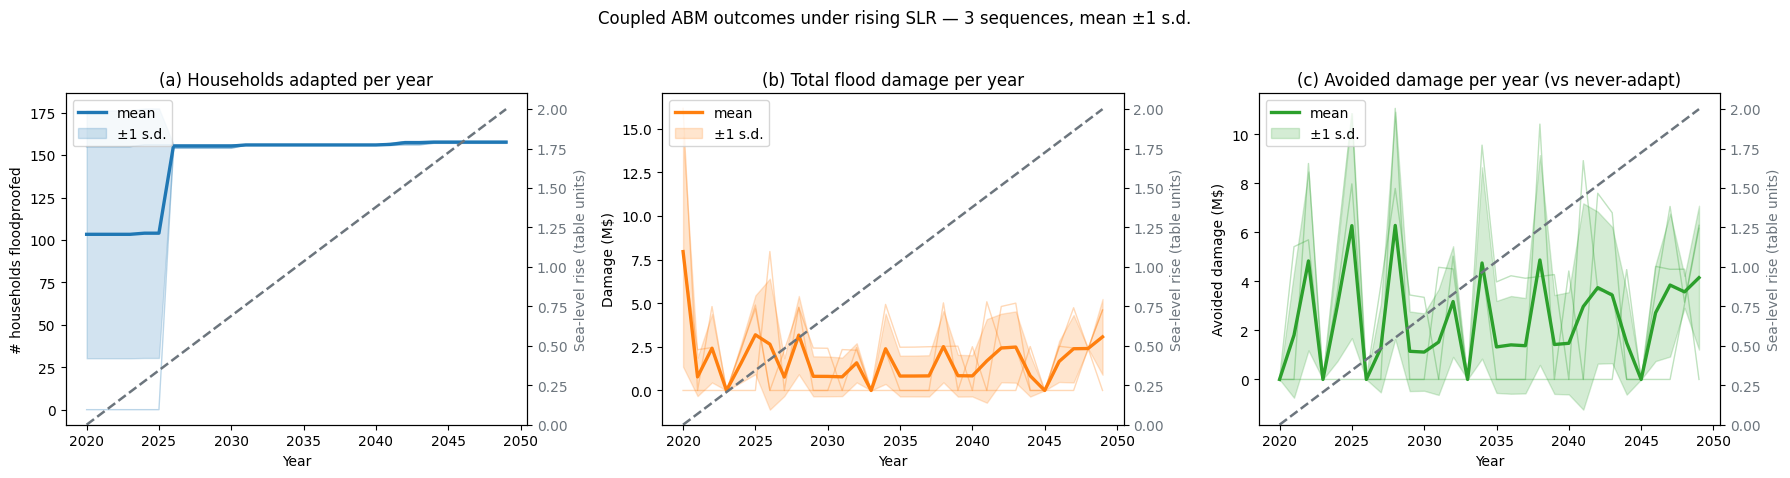

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
slr_color = "#6c757d"

def overlay_slr(ax):
    axr = ax.twinx()
    axr.plot(years, slr_values, color=slr_color, ls="--", lw=1.8, label="SLR")
    axr.set_ylabel("Sea-level rise (table units)", color=slr_color)
    axr.tick_params(axis="y", labelcolor=slr_color)
    axr.set_ylim(bottom=min(0, float(slr_values.min())))
    return axr

# (a) Number of households adapted per year -----------------------------------
ax = axes[0]
for s in range(NO_SEQ):
    ax.plot(years, n_adapted[s], color="C0", alpha=0.30, lw=1)
m, sd = n_adapted.mean(0), n_adapted.std(0)
ax.plot(years, m, color="C0", lw=2.4, label="mean")
ax.fill_between(years, m - sd, m + sd, color="C0", alpha=0.20, label="±1 s.d.")
ax.set_title("(a) Households adapted per year")
ax.set_xlabel("Year"); ax.set_ylabel("# households floodproofed")
ax.legend(loc="upper left"); overlay_slr(ax)

# (b) Total damage per year ---------------------------------------------------
ax = axes[1]
for s in range(NO_SEQ):
    ax.plot(years, dmg_year[s], color="C1", alpha=0.30, lw=1)
m, sd = dmg_year.mean(0), dmg_year.std(0)
ax.plot(years, m, color="C1", lw=2.4, label="mean")
ax.fill_between(years, m - sd, m + sd, color="C1", alpha=0.20, label="±1 s.d.")
ax.set_title("(b) Total flood damage per year")
ax.set_xlabel("Year"); ax.set_ylabel("Damage (M$)")
ax.legend(loc="upper left"); overlay_slr(ax)

# (c) Total avoided damage per year -------------------------------------------
ax = axes[2]
for s in range(NO_SEQ):
    ax.plot(years, avoided_year[s], color="C2", alpha=0.30, lw=1)
m, sd = avoided_year.mean(0), avoided_year.std(0)
ax.plot(years, m, color="C2", lw=2.4, label="mean")
ax.fill_between(years, m - sd, m + sd, color="C2", alpha=0.20, label="±1 s.d.")
ax.set_title("(c) Avoided damage per year (vs never-adapt)")
ax.set_xlabel("Year"); ax.set_ylabel("Avoided damage (M$)")
ax.legend(loc="upper left"); overlay_slr(ax)

fig.suptitle("Coupled ABM outcomes under rising SLR — 3 sequences, mean ±1 s.d.", y=1.03)
fig.tight_layout()
plt.show()

## 9. Insights (plain language)

The cell below turns the headline numbers into a short narrative for non-technical stakeholders. It reads directly from the arrays above, so it stays correct if you change the scenario.

In [6]:
final_adopt_pct = adoption[:, -1].mean() * 100
peak_dmg   = dmg_year.mean(0).max()
cum_dmg    = dmg_year.sum(1).mean()
cum_avoid  = avoided_year.sum(1).mean()
avoid_share = 100 * cum_avoid / (cum_dmg + cum_avoid) if (cum_dmg + cum_avoid) > 0 else 0.0

print("KEY TAKEAWAYS")
print("-" * 68)
print(f"* Sea level rises from {slr_values[0]:.2f} to {slr_values[-1]:.2f} over {N_YEARS} yr.")
print(f"* By year {years[-1]}, on average {final_adopt_pct:.0f}% of households have floodproofed.")
print(f"* Peak mean annual flood damage is about ${peak_dmg:.1f}M.")
print(f"* Over the horizon, adaptation avoids ~${cum_avoid:.0f}M of damage")
print(f"  (~{avoid_share:.0f}% of what damage would otherwise have been).")
print(f"* Spread across the 3 sequences is the uncertainty from stochastic flood timing.")

KEY TAKEAWAYS
--------------------------------------------------------------------
* Sea level rises from 0.00 to 2.00 over 30 yr.
* By year 2049, on average 99% of households have floodproofed.
* Peak mean annual flood damage is about $8.0M.
* Over the horizon, adaptation avoids ~$73M of damage
  (~58% of what damage would otherwise have been).
* Spread across the 3 sequences is the uncertainty from stochastic flood timing.


## 10. The native mirror — same results **without** mesa/honeybees

The Section-6 run used the real **honeybees** framework (when installed). The coupling also ships
a **dependency-free mirror** that reproduces the honeybees driving loop in plain NumPy:

- `run_mesa_native` — mirrors the honeybees `Model` tick loop exactly.
- `engine.run(n_jobs=...)` — owns its own loop and adds Monte-Carlo **parallelism**.

**Why it exists.** Not every deployment can install mesa/honeybees (locked-down environments, CI,
lightweight services). The mirror lets the coupling run **anywhere** while guaranteeing the *same*
science — because all three paths call the **identical `SimulationEngine.step` kernel with the
identical RNG stream**. That equivalence is the Phase-4b / 4b-full **gate**.

**When to use which**

| Situation | Use |
|---|---|
| Full agent-based fidelity, DYNAMO-M ecosystem present | `run_mesa_native_full` (§6) |
| No mesa/honeybees; must run anywhere (CI, services) | `run_mesa_native` |
| Many sequences, need speed (bit-identical) | `engine.run(n_jobs=-1)` |

Below we run the mirror and the parallel engine, then **assert bit-for-bit equality** with §6.

PARITY OK: run_mesa_native  ==  engine.run(n_jobs=-1)  ==  Section-6 run  (bit-for-bit)


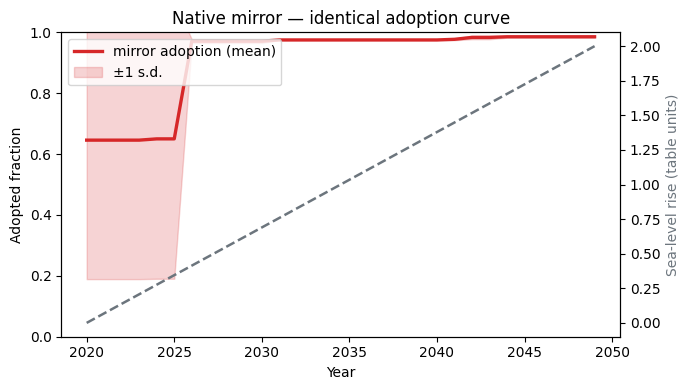

In [7]:
# Portable mirror (no honeybees needed) and the parallel engine — same seeds.
mirror   = run_mesa_native(engine, slr_values, no_seq=NO_SEQ, seed=SEED, track_eu=True)
parallel = engine.run(slr_values, no_seq=NO_SEQ, seed=SEED, n_jobs=-1)

# Bit-for-bit equality is the coupling's correctness contract.
assert np.array_equal(mirror["damage_history"],  results["damage_history"]),  "mirror != preferred"
assert np.array_equal(mirror["adapted_history"], results["adapted_history"]), "mirror != preferred"
assert np.array_equal(parallel["damage_history"],  results["damage_history"]),  "parallel != preferred"
assert np.array_equal(parallel["adapted_history"], results["adapted_history"]), "parallel != preferred"
print("PARITY OK: run_mesa_native  ==  engine.run(n_jobs=-1)  ==  Section-6 run  (bit-for-bit)")

# Same headline (adoption) from the mirror, with SLR overlaid.
mad = mirror["adoption_fraction"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(years, mad.mean(0), color="C3", lw=2.4, label="mirror adoption (mean)")
ax.fill_between(years, mad.mean(0) - mad.std(0), mad.mean(0) + mad.std(0),
                color="C3", alpha=0.2, label="±1 s.d.")
ax.set_xlabel("Year"); ax.set_ylabel("Adopted fraction"); ax.set_ylim(0, 1)
ax.set_title("Native mirror — identical adoption curve"); ax.legend(loc="upper left")
axr = ax.twinx(); axr.plot(years, slr_values, color="#6c757d", ls="--", lw=1.8)
axr.set_ylabel("Sea-level rise (table units)", color="#6c757d")
plt.tight_layout(); plt.show()

## 11. Extend & configure (Strategy Pattern)

The decision logic is **pluggable** — swap the rule, keep the engine:

```python
# Legacy 0.30-threshold behaviour (reproduces the old ABMSimulator bit-for-bit):
engine = SimulationEngine(ds=ds, config=config,
                          decision_rule=ThresholdRule(config.decision, 0.30))

# Live native DYNAMO-M decision module (parity oracle; needs a DYNAMO-M checkout):
if DYNAMO_M_AVAILABLE:
    engine = SimulationEngine(ds=ds, config=config,
                              decision_rule=DynamoLiveRule(config.decision))

# Custom rule: subclass DecisionRule and implement evaluate_decisions(...).
```

**Where to go next**

- Runnable, self-contained examples: `examples_engine/01…07_*.py` (07 = this full path).
- Architecture, SEU math, phase history & roadmap: `docs/architecture.md`.
- Whole-repo API reference: `floodadapt_abm_documentation.md`.
- DYNAMO-M decision science: `docs/adaptation_decisions_complete.md`.

*Future phases* add insurance, migration/gravity, and government/dike cost-benefit as **new
rules/agents** — never as surgery on this kernel.
